# What Separates Winners? A Data-Driven Analysis of NCAA Division I Men's Basketball (2026)

## Introduction

This notebook analyzes the 2025–26 NCAA Division I men's basketball season using data collected 
from the ESPN API. The dataset spans 362 Division I programs and includes season-level team 
performance, game-by-game results, and individual player roster data.

## Target Audience

This analysis is written for athletic department strategy teams, conference offices, and 
basketball operations staff interested in understanding what measurable factors separate 
winning programs from losing ones across the full D1 landscape.

## Central Question

What separates winning programs in NCAA Division I men's basketball — and can those factors 
be measured, quantified, and used to predict outcomes?

## Approach

The analysis moves from the broad to the specific: starting with the structure of D1 as a 
whole, then narrowing to conference performance, team-level drivers of winning, roster 
composition, and finally predictive modeling of game outcomes and season win rates.

## Data Source

All data was collected via the ESPN Core and Site APIs for the 2025–26 season and processed 
through Snowflake before being loaded here for analysis. The dataset includes:
- **362** Division I teams across **31** conferences
- **11,954** completed regular season and postseason games
- **5,648** individual player roster records

## Section 1: Environment Setup & Data Load

In [43]:
! pip install python-dotenv
! pip install snowflake-connector-python[pandas]

from dotenv import load_dotenv
import snowflake.connector
import os
import pandas as pd
import requests

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import ( 
    accuracy_score, precision_score, recall_score, f1_score, classification_report, r2_score, 
    mean_absolute_error, mean_squared_error, confusion_matrix, roc_auc_score
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [44]:
load_dotenv()

conn = snowflake.connector.connect(
    user=os.getenv("SNOWFLAKE_USER"),
    password=os.getenv("SNOWFLAKE_PASSWORD"),
    account=os.getenv("SNOWFLAKE_ACCOUNT"),
    warehouse=os.getenv("SNOWFLAKE_WAREHOUSE"),
    database=os.getenv("SNOWFLAKE_DATABASE"),
    schema=os.getenv("SNOWFLAKE_SCHEMA")
)

In [45]:
df_views = pd.read_sql("""
    SELECT table_name 
    FROM information_schema.views 
    WHERE table_schema = CURRENT_SCHEMA()
""", conn)
print(df_views)

C:\Users\Owner\AppData\Local\Temp\ipykernel_24212\2181744936.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_views = pd.read_sql("""


               TABLE_NAME
0   VW_RECORD_STATS_CLEAN
1           VW_D1_PLAYERS
2             VW_D1_TEAMS
3         VW_GROUPS_CLEAN
4             VW_D1_GAMES
5      VW_D1_GAMES_UNIQUE
6  VW_TEAM_CLASSIFICATION
7          VW_TEAMS_CLEAN
8  VW_TEAM_RECORD_SUMMARY


In [46]:
df_d1_teams = pd.read_sql("SELECT * FROM vw_d1_teams", conn)
df_d1_players = pd.read_sql("SELECT * FROM vw_d1_players", conn)
df_d1_games = pd.read_sql("SELECT * FROM vw_d1_games", conn)
df_d1_games_unique = pd.read_sql("SELECT * FROM vw_d1_games_unique", conn)

C:\Users\Owner\AppData\Local\Temp\ipykernel_24212\3584338800.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_d1_teams = pd.read_sql("SELECT * FROM vw_d1_teams", conn)
C:\Users\Owner\AppData\Local\Temp\ipykernel_24212\3584338800.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_d1_players = pd.read_sql("SELECT * FROM vw_d1_players", conn)
C:\Users\Owner\AppData\Local\Temp\ipykernel_24212\3584338800.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_d1_games = pd.read_sql("SELECT * FROM vw_d1_games", conn)
C:\

In [47]:
print(f"df_d1_teams:        {df_d1_teams.shape}")
print(f"df_d1_players:      {df_d1_players.shape}")
print(f"df_d1_games:        {df_d1_games.shape}")
print(f"df_d1_games_unique: {df_d1_games_unique.shape}")

df_d1_teams:        (362, 20)
df_d1_players:      (5648, 19)
df_d1_games:        (11986, 16)
df_d1_games_unique: (6309, 11)


The four core tables loaded above form the backbone of this analysis. Teams and players provide 
season-level and roster-level context. Games and unique games provide the game-level outcomes 
used for both EDA and modeling. All views were pre-built and validated in Snowflake before 
being loaded here.

## Section 2: Data Quality

Before drawing any conclusions, we validate the data across all four tables. This section 
checks for missing values, unexpected values, and structural oddities that could affect 
downstream analysis. Any issues found here are addressed before EDA begins.

In [48]:
print(f"Conferences:  {df_d1_teams['CONFERENCE'].nunique()}")
print(f"Divisions:    {df_d1_teams['DIVISION'].nunique()}")
print(f"Positions:    {df_d1_players['POSITION'].nunique()}")
print(f"Home/Away:    {df_d1_games['HOME_AWAY'].nunique()}")
print()
print("Home/Away values:  ", df_d1_games['HOME_AWAY'].unique())
print("Position values:   ", df_d1_players['POSITION'].unique())
print("Division values:   ", df_d1_teams['DIVISION'].unique())

Conferences:  31
Divisions:    1
Positions:    8
Home/Away:    2

Home/Away values:   ['away' 'home']
Position values:    ['G' 'F' 'C' 'PG' 'PF' 'NA' 'SG' 'SF']
Division values:    ['NCAA Division I']


In [49]:
# dtype check across all four tables
print("--- df_d1_teams ---")
print(df_d1_teams.dtypes)
print("\n--- df_d1_players ---")
print(df_d1_players.dtypes)
print("\n--- df_d1_games ---")
print(df_d1_games.dtypes)
print("\n--- df_d1_games_unique ---")
print(df_d1_games_unique.dtypes)

--- df_d1_teams ---
TEAM_ID          object
SEASON            int64
TEAM_NAME        object
ABBREVIATION     object
LOCATION         object
MASCOT           object
CONFERENCE       object
DIVISION         object
WINS            float64
LOSSES          float64
WIN_PCT         float64
PPG             float64
OPP_PPG         float64
POINT_DIFF      float64
HOME_WINS       float64
HOME_LOSSES     float64
AWAY_WINS       float64
AWAY_LOSSES     float64
CONF_WINS       float64
CONF_LOSSES     float64
dtype: object

--- df_d1_players ---
ATHLETE_ID        object
TEAM_ID           object
SEASON             int64
TEAM_NAME         object
CONFERENCE        object
PLAYER_NAME       object
FIRST_NAME        object
LAST_NAME         object
JERSEY            object
POSITION          object
POSITION_NAME     object
HEIGHT           float64
WEIGHT           float64
YEAR              object
YEARS_EXP        float64
CITY              object
STATE             object
COUNTRY           object
ACTIVE       

In [50]:
def null_summary(df, name):
    summary = df.isnull().sum().reset_index()
    summary.columns = ["column", "null_count"]
    summary["pct_missing"] = (summary["null_count"] / len(df) * 100).round(2)
    summary = summary[summary["null_count"] > 0].sort_values("pct_missing", ascending=False)
    summary.insert(0, "table", name)
    return summary

pd.concat([
    null_summary(df_d1_teams, "teams"),
    null_summary(df_d1_players, "players"),
    null_summary(df_d1_games, "games"),
    null_summary(df_d1_games_unique, "games_unique")
]).reset_index(drop=True)

,table,column,null_count,pct_missing
0,players,STATE,831,14.71
1,players,WEIGHT,274,4.85
2,players,JERSEY,37,0.66
3,players,HEIGHT,35,0.62
4,players,YEAR,32,0.57
5,players,YEARS_EXP,32,0.57
6,players,CITY,32,0.57
7,players,COUNTRY,32,0.57
8,games,WON,32,0.27


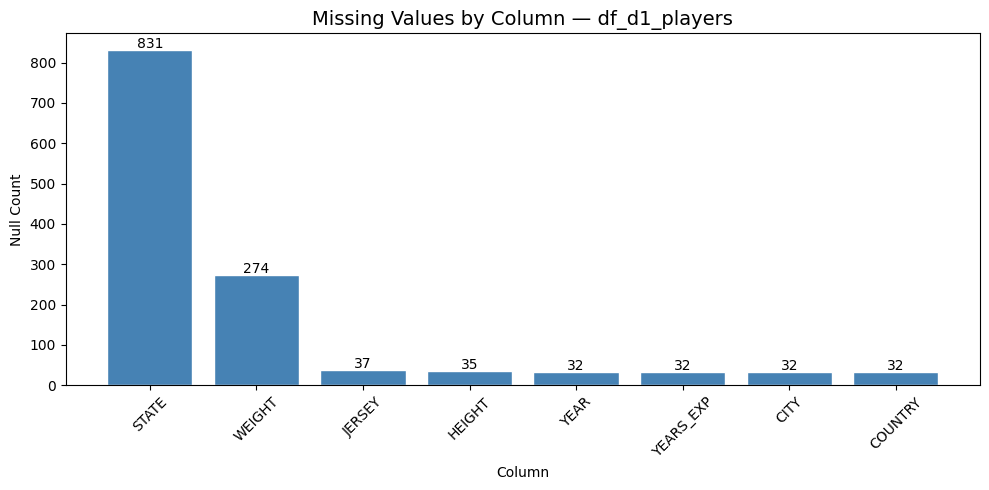

In [51]:
fig, ax = plt.subplots(figsize=(10, 5))

null_counts = df_d1_players.isnull().sum()
null_counts = null_counts[null_counts > 0].sort_values(ascending=False)

ax.bar(null_counts.index, null_counts.values, color="steelblue", edgecolor="white")
ax.set_title("Missing Values by Column — df_d1_players", fontsize=14)
ax.set_xlabel("Column")
ax.set_ylabel("Null Count")
ax.tick_params(axis="x", rotation=45)

for i, v in enumerate(null_counts.values):
    ax.text(i, v + 5, str(v), ha="center", fontsize=10)

plt.tight_layout()
plt.show()

The chart confirms that missing data is concentrated in a small number of player 
attributes — STATE, WEIGHT, and JERSEY — while all team and game records are complete.

In [52]:
# Check if missing state is just international players
df_d1_players[df_d1_players["STATE"].isnull()]["COUNTRY"].value_counts().head(10)

COUNTRY
France         62
Nigeria        44
Senegal        41
Serbia         39
Germany        37
England        35
Spain          32
Lithuania      28
New Zealand    22
Italy          21
Name: count, dtype: int64

In [53]:
print("Teams with 0 wins:")
print(df_d1_teams[df_d1_teams["WINS"] == 0][["TEAM_NAME", "CONFERENCE", "WINS", "LOSSES"]])

print("\nTeams with PPG below 50 or above 110:")
print(df_d1_teams[(df_d1_teams["PPG"] < 50) | (df_d1_teams["PPG"] > 110)][["TEAM_NAME", "PPG", "WINS"]])

print("\nGames with score of 0:")
print(df_d1_games[(df_d1_games["TEAM_SCORE"] == 0) | (df_d1_games["OPP_SCORE"] == 0)].shape[0])

Teams with 0 wins:
Empty DataFrame
Columns: [TEAM_NAME, CONFERENCE, WINS, LOSSES]
Index: []

Teams with PPG below 50 or above 110:
Empty DataFrame
Columns: [TEAM_NAME, PPG, WINS]
Index: []

Games with score of 0:
32


In [54]:
df_d1_games[df_d1_games["WON"].isnull()]["GAME_ID"].nunique()

17

In [55]:
df_d1_games = df_d1_games[df_d1_games["WON"].notnull()].copy()
df_d1_games.shape

(11954, 16)

In [56]:
played_game_ids = df_d1_games["GAME_ID"].unique()
df_d1_games_unique = df_d1_games_unique[df_d1_games_unique["GAME_ID"].isin(played_game_ids)].copy()
df_d1_games_unique.shape

(6292, 11)

### Data Quality Summary

The data quality checks confirm the dataset is clean and ready for analysis:

- **No missing values** in teams or unique games tables
- **Player nulls are expected** — missing weight (4.9%), state (14.7%), and height (<1%) 
  reflect incomplete ESPN roster data, concentrated in smaller programs and international 
  players. These fields are not used as primary analysis inputs.
- **32 incomplete games identified and removed** — ESPN returned a score of 0 and no 
  win/loss result for 17 unique games (32 team-game rows). These were filtered before 
  analysis, leaving 11,954 completed games and 6,292 unique games.
- **No structural oddities** — no teams with zero wins and no impossible scoring values 
  in the completed game set
- **Categorical values are clean** — HOME_AWAY contains only "home" and "away", 
  all teams map to a single division (NCAA Division I), and all 31 conferences 
  are consistently labeled

The dataset is ready for analysis with no additional corrections needed.

## Section 3: The D1 Landscape

With a clean dataset in hand, we start broad. This section establishes what NCAA Division I 
men's basketball looks like structurally in 2026 — how the division is organized across 
conferences, how competitive the field is, and what the scoring environment looks like 
league-wide. This context is essential before asking which teams and conferences perform best.

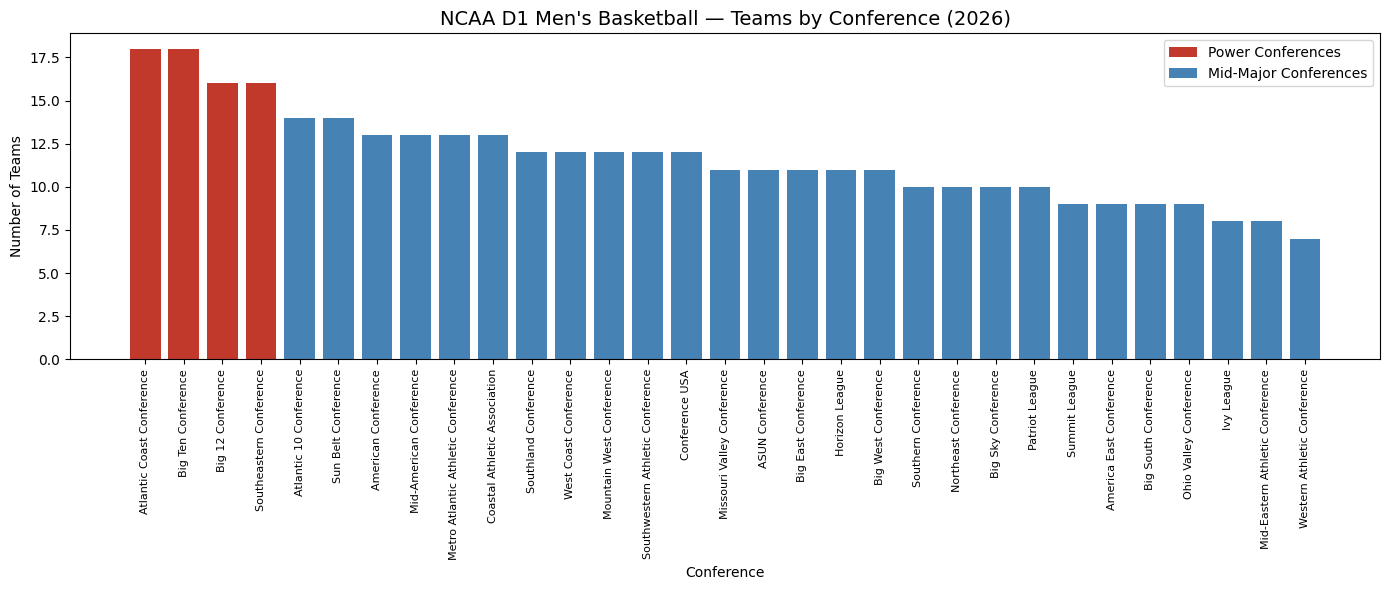

In [57]:
# Teams per conference
conf_counts = df_d1_teams.groupby("CONFERENCE")["TEAM_ID"].count().sort_values(ascending=False).reset_index()
conf_counts.columns = ["conference", "team_count"]

power_conferences = ["Atlantic Coast Conference", "Big Ten Conference", "Big 12 Conference", "Southeastern Conference"]

colors = ["#c0392b" if c in power_conferences else "steelblue" for c in conf_counts["conference"]]

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(conf_counts["conference"], conf_counts["team_count"], color=colors)

ax.set_title("NCAA D1 Men's Basketball — Teams by Conference (2026)", fontsize=14)
ax.set_xlabel("Conference")
ax.set_ylabel("Number of Teams")
ax.tick_params(axis="x", rotation=90, labelsize=8)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#c0392b", label="Power Conferences"),
                   Patch(facecolor="steelblue", label="Mid-Major Conferences")]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

D1 spans 31 conferences ranging from 7 to 18 teams. The four power conferences — ACC, 
Big 12, Big Ten, and SEC — are highlighted in red. While they don't differ dramatically 
in size from mid-majors, their resource advantages and recruiting footprints make them 
structurally distinct from the rest of the field.

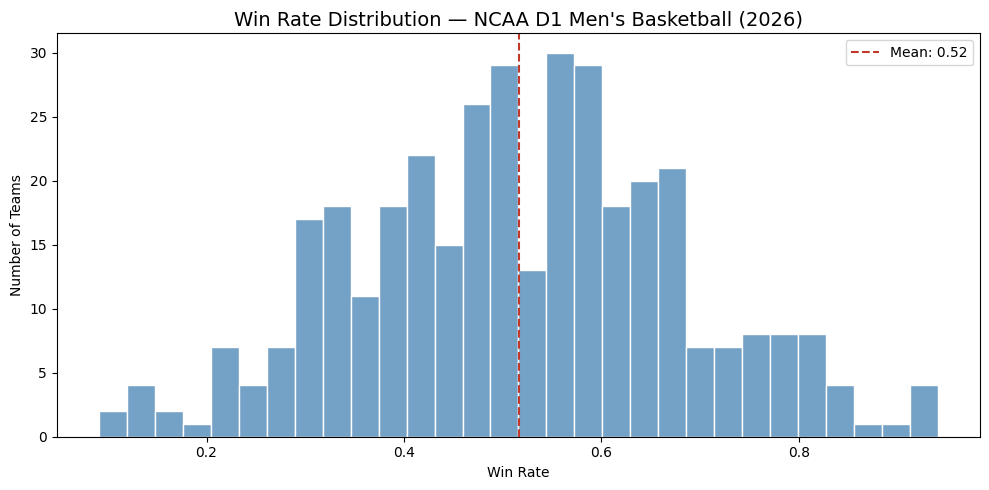

In [58]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df_d1_teams["WIN_PCT"], bins=30, color="steelblue", edgecolor="white", ax=ax)
ax.axvline(df_d1_teams["WIN_PCT"].mean(), color="#c0392b", linestyle="--", linewidth=1.5, label=f"Mean: {df_d1_teams['WIN_PCT'].mean():.2f}")
ax.set_title("Win Rate Distribution — NCAA D1 Men's Basketball (2026)", fontsize=14)
ax.set_xlabel("Win Rate")
ax.set_ylabel("Number of Teams")
ax.legend()
plt.tight_layout()
plt.show()

Win rate across D1 follows a roughly normal distribution centered at 0.52. The slight 
rightward skew reflects a small group of elite programs pulling the mean above 0.50. 
The spread from near 0.10 to 0.95 confirms meaningful variation in program quality 
across the division.

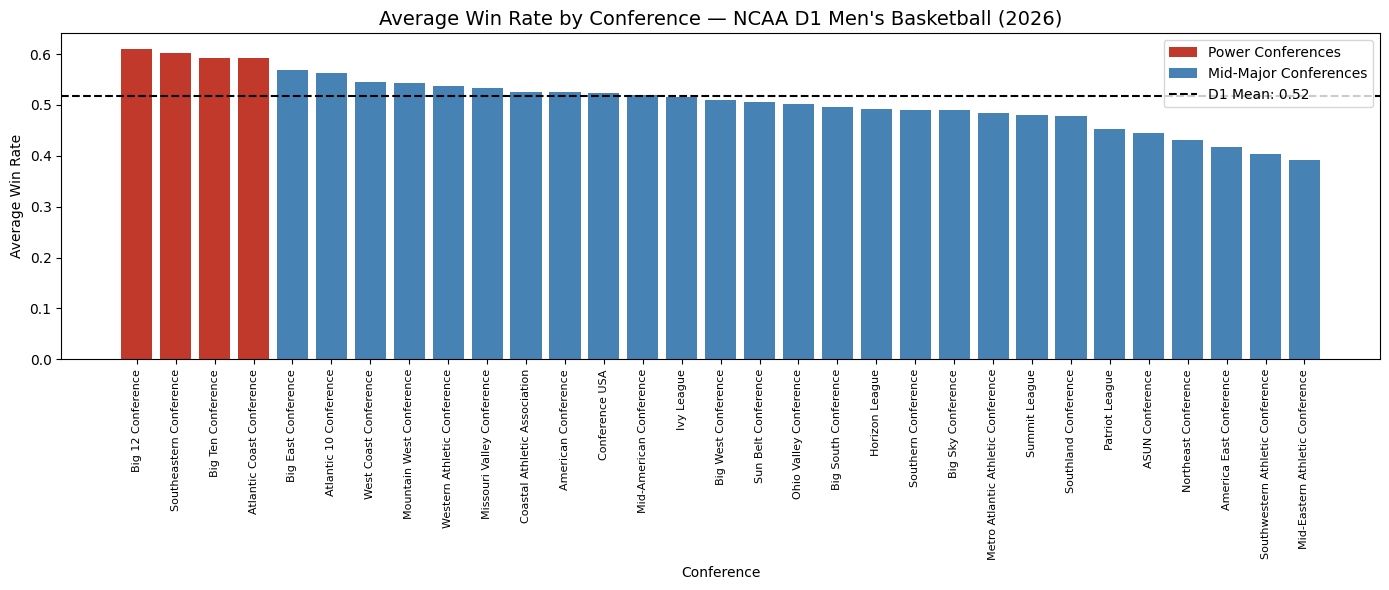

In [59]:
conf_wins = df_d1_teams.groupby("CONFERENCE")["WIN_PCT"].mean().sort_values(ascending=False).reset_index()
conf_wins.columns = ["conference", "avg_win_pct"]

power_conferences = ["Atlantic Coast Conference", "Big Ten Conference", "Big 12 Conference", "Southeastern Conference"]
colors = ["#c0392b" if c in power_conferences else "steelblue" for c in conf_wins["conference"]]

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(conf_wins["conference"], conf_wins["avg_win_pct"], color=colors)
ax.axhline(df_d1_teams["WIN_PCT"].mean(), color="black", linestyle="--", linewidth=1.5, label=f"D1 Mean: {df_d1_teams['WIN_PCT'].mean():.2f}")
ax.set_title("Average Win Rate by Conference — NCAA D1 Men's Basketball (2026)", fontsize=14)
ax.set_xlabel("Conference")
ax.set_ylabel("Average Win Rate")
ax.tick_params(axis="x", rotation=90, labelsize=8)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#c0392b", label="Power Conferences"),
                   Patch(facecolor="steelblue", label="Mid-Major Conferences"),
                   plt.Line2D([0], [0], color="black", linestyle="--", label=f"D1 Mean: {df_d1_teams['WIN_PCT'].mean():.2f}")]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

The four power conferences — Big 12, SEC, ACC, and Big Ten — all sit above the D1 mean 
win rate of 0.52, confirming that structural advantages in recruiting and resources translate 
to on-court results. The Big 12 leads at 0.61, notable given its recent expansion. 
Mid-majors like the Big East and Atlantic 10 are competitive but the drop-off below the 
mean accelerates toward the smaller conferences at the bottom of the division.

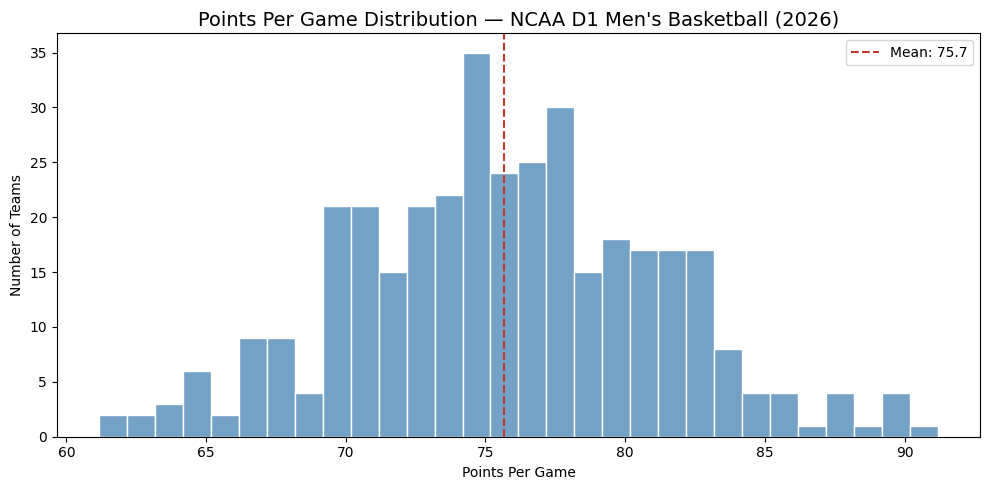

In [60]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df_d1_teams["PPG"], bins=30, color="steelblue", edgecolor="white", ax=ax)
ax.axvline(df_d1_teams["PPG"].mean(), color="#c0392b", linestyle="--", linewidth=1.5, label=f"Mean: {df_d1_teams['PPG'].mean():.1f}")
ax.set_title("Points Per Game Distribution — NCAA D1 Men's Basketball (2026)", fontsize=14)
ax.set_xlabel("Points Per Game")
ax.set_ylabel("Number of Teams")
ax.legend()
plt.tight_layout()
plt.show()

Scoring across D1 is tightly clustered between 70 and 82 points per game, with a mean 
of 75.5. The distribution is roughly normal with a slight right tail driven by a small 
group of high-tempo programs. Very few teams average below 65 or above 90, suggesting 
the scoring environment is relatively consistent across the division.

In [61]:
conf_summary = df_d1_teams.groupby("CONFERENCE")[["WIN_PCT", "PPG", "OPP_PPG", "POINT_DIFF"]].mean().round(2).sort_values("WIN_PCT", ascending=False)
conf_summary.index.name = "Conference"
conf_summary.columns = ["Avg Win Rate", "Avg PPG", "Avg Opp PPG", "Avg Point Diff"]
conf_summary

,Avg Win Rate,Avg PPG,Avg Opp PPG,Avg Point Diff
Conference,,,,
Big 12 Conference,0.61,78.85,73.58,5.28
Southeastern Conference,0.60,82.93,77.11,5.82
Atlantic Coast Conference,0.59,77.88,73.02,4.88
Big Ten Conference,0.59,76.83,72.15,4.68
Big East Conference,0.57,76.56,73.36,3.23
Atlantic 10 Conference,0.56,74.78,71.34,3.42
West Coast Conference,0.55,75.55,72.71,2.83
Western Athletic Conference,0.54,74.40,71.90,2.47
Mountain West Conference,0.54,75.77,73.32,2.44


The SEC stands out as the highest-scoring conference at 82.93 PPG despite ranking second 
in win rate — suggesting an up-tempo style relative to the rest of D1. The Big 12 wins 
more while scoring less, pointing to a more defense-oriented identity. Point differential 
tells a cleaner story than win rate alone: the gap between power and mid-major conferences 
widens when measured by margin rather than just record.

In [62]:
df_d1_teams[["WINS", "LOSSES", "WIN_PCT", "PPG", "OPP_PPG", "POINT_DIFF"]].describe().round(2)

,WINS,LOSSES,WIN_PCT,PPG,OPP_PPG,POINT_DIFF
count,362.00,362.00,362.00,362.00,362.00,362.00
mean,17.26,15.76,0.52,75.67,74.01,1.66
std,6.18,5.00,0.16,5.52,4.71,6.32
min,3.00,2.00,0.09,61.16,61.75,-18.80
25%,13.00,12.00,0.40,72.04,70.75,-2.20
50%,17.00,16.00,0.52,75.42,73.95,1.80
75%,21.00,19.00,0.62,79.36,77.34,5.50
max,37.00,30.00,0.94,91.20,88.28,18.40


The summary statistics reinforce the breadth of the D1 field. The average team wins 52% 
of games and scores 75.7 points per game. Win rate ranges from 0.09 to 0.94, point 
differential spans from -18.8 to +18.4, and PPG ranges from 61 to 91. The interquartile 
range for win rate runs from 0.40 to 0.62, meaning the middle 50% of D1 programs are 
reasonably competitive — but the tails are wide, confirming meaningful separation between 
the division's strongest and weakest programs.

## Section 4: What Separates Winners?

The landscape section established that D1 is a wide field with meaningful variation in 
team quality. The next question is: what actually drives that variation? This section 
examines the performance metrics most strongly associated with winning — starting with 
scoring margin, then layering in conference context, home court advantage, and the 
relationship between offense and defense. The goal is to identify which measurable factors 
best explain why some programs win consistently and others don't.

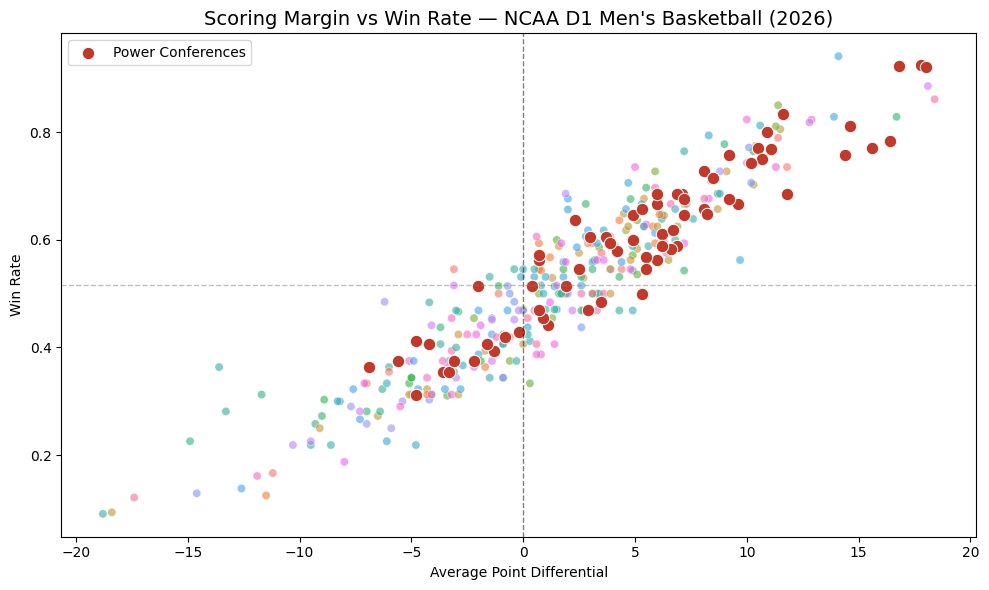

In [63]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df_d1_teams, x="POINT_DIFF", y="WIN_PCT", 
                hue="CONFERENCE", legend=False, alpha=0.6, ax=ax)

# Add power conference teams as highlighted points
power_conferences = ["Atlantic Coast Conference", "Big Ten Conference", "Big 12 Conference", "Southeastern Conference"]
power_teams = df_d1_teams[df_d1_teams["CONFERENCE"].isin(power_conferences)]
sns.scatterplot(data=power_teams, x="POINT_DIFF", y="WIN_PCT",
                color="#c0392b", label="Power Conferences", s=80, ax=ax)

ax.axvline(0, color="black", linestyle="--", linewidth=1, alpha=0.5)
ax.axhline(df_d1_teams["WIN_PCT"].mean(), color="gray", linestyle="--", linewidth=1, alpha=0.5)
ax.set_title("Scoring Margin vs Win Rate — NCAA D1 Men's Basketball (2026)", fontsize=14)
ax.set_xlabel("Average Point Differential")
ax.set_ylabel("Win Rate")
ax.legend()
plt.tight_layout()
plt.show()

The relationship between point differential and win rate is nearly linear across all 362 
D1 programs. Teams with a positive scoring margin almost universally win more than half 
their games, and teams with a negative margin do the opposite. There are very few exceptions 
— the quadrants are clean. Power conference teams cluster in the upper right, winning by 
large margins consistently, while the bottom of the division sits in the lower left. This 
single metric — how much you win or lose by — tracks season success more closely than 
almost anything else we can measure.

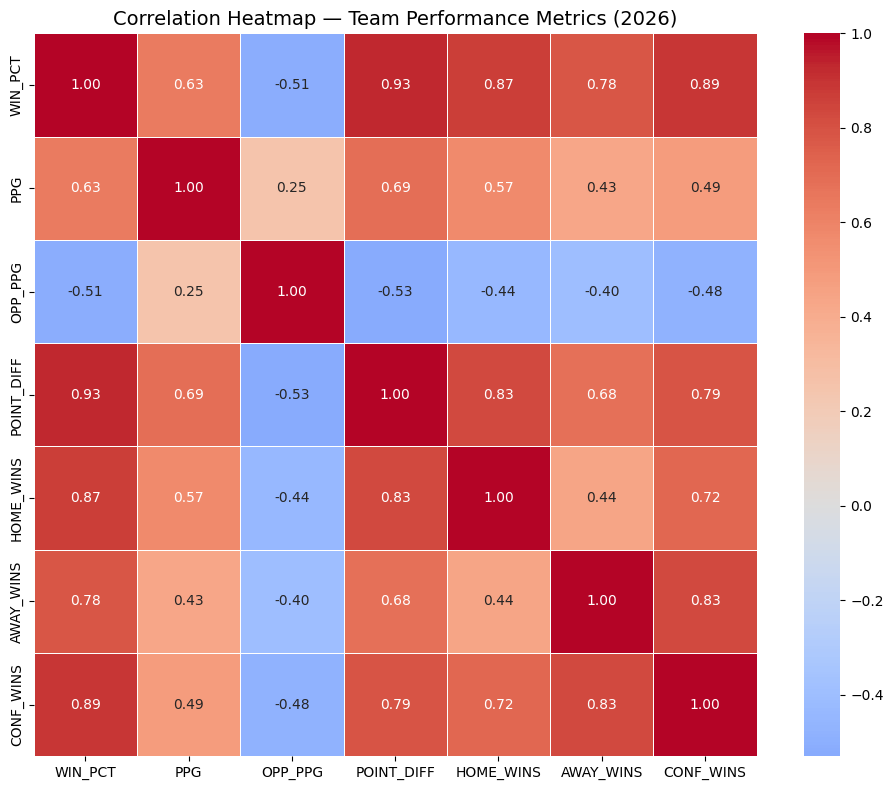

In [64]:
corr_cols = ["WIN_PCT", "PPG", "OPP_PPG", "POINT_DIFF", "HOME_WINS", "AWAY_WINS", "CONF_WINS"]
corr_matrix = df_d1_teams[corr_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", 
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlation Heatmap — Team Performance Metrics (2026)", fontsize=14)
plt.tight_layout()
plt.show()

The correlation heatmap quantifies what the scatter plot showed visually. Key takeaways:

- **Point differential (0.93)** is the strongest predictor of win rate — stronger than 
  any individual component
- **Home wins (0.87) and conference wins (0.89)** are highly correlated with overall 
  win rate, reflecting that teams that win at home and in conference tend to win overall
- **Away wins (0.78)** have a lower correlation than home wins, consistent with the 
  home court advantage finding — road wins are harder to accumulate and less predictable
- **PPG (0.63) vs OPP_PPG (-0.51)** — offense and defense both matter, but offense 
  correlates more strongly with winning than defense does in this dataset
- **PPG and OPP_PPG are positively correlated (0.25)** — high-scoring teams also tend 
  to give up more points, suggesting pace of play affects both sides of the ball equally

The dominant signal is clear: winning by more points, more consistently, across all 
game contexts is what separates D1's best programs from the rest.

In [65]:
df_d1_games["WON"] = df_d1_games["WON"].astype(int)
df_d1_games["LOCATION"] = df_d1_games.apply(
    lambda row: "Neutral" if row["NEUTRAL_SITE"] == True else row["HOME_AWAY"].capitalize(), axis=1
)

location_summary = df_d1_games.groupby("LOCATION")["WON"].mean().round(3).reset_index()
location_summary.columns = ["Location", "Win Rate"]
location_summary

,Location,Win Rate
0,Away,0.356
1,Home,0.679
2,Neutral,0.502


Home court advantage is one of the most consistent findings in the data. Home teams win 
67.9% of games while away teams win only 35.6% — a 32 percentage point gap. Neutral site 
games land almost exactly at 50.2%, confirming that when neither team has a home court 
the outcome is essentially a coin flip. This finding will be used as a feature in the 
predictive models in Section 8.

## Section 5: The AP Rankings Lens

The analysis so far has treated all 362 D1 teams equally. To validate our performance 
metrics against an established external benchmark, we bring in the 2025-26 AP Top 25 
poll rankings. The AP poll represents the consensus view of college basketball analysts 
and voters — if our metrics are meaningful, ranked teams should look materially different 
from unranked teams across every dimension we have measured so far.

In [66]:
# pull AP Top 25 rankings from ESPN API for the 2025-26 season
rankings_raw = requests.get(
    "https://site.api.espn.com/apis/site/v2/sports/basketball/mens-college-basketball/rankings",
    params={"season": 2026, "seasontype": 3}
).json()

# find the AP Top 25 poll in the response
ap_poll = next(
    p for p in rankings_raw["rankings"]
    if "AP" in p["name"]
)

# extract team id and rank
ap_rows = []
for entry in ap_poll["ranks"]:
    ap_rows.append({
        "TEAM_ID": str(entry["team"]["id"]),
        "AP_RANK": entry["current"],
        "AP_POINTS": entry.get("points")
    })

ap_df = pd.DataFrame(ap_rows)
print(f"AP poll teams: {len(ap_df)}")
ap_df.head()

AP poll teams: 25


,TEAM_ID,AP_RANK,AP_POINTS
0,130,1,1425.0
1,41,2,1352.0
2,12,3,1311.0
3,150,4,1237.0
4,356,5,1228.0


In [67]:
df_d1_teams["TEAM_ID"] = df_d1_teams["TEAM_ID"].astype(str)
df_d1_teams = df_d1_teams.merge(ap_df, on="TEAM_ID", how="left")
df_d1_teams["IS_RANKED"] = df_d1_teams["AP_RANK"].notna().astype(int)

print(f"AP ranked teams matched: {df_d1_teams['IS_RANKED'].sum()}")
df_d1_teams[df_d1_teams["IS_RANKED"] == 1][["TEAM_NAME", "CONFERENCE", "WINS", "WIN_PCT", "AP_RANK"]].sort_values("AP_RANK")

AP ranked teams matched: 25


,TEAM_NAME,CONFERENCE,WINS,WIN_PCT,AP_RANK
61,Michigan Wolverines,Big Ten Conference,37.0,0.925000,1.0
18,UConn Huskies,Big East Conference,34.0,0.850000,2.0
5,Arizona Wildcats,Big 12 Conference,36.0,0.923077,3.0
69,Duke Blue Devils,Atlantic Coast Conference,35.0,0.921053,4.0
164,Illinois Fighting Illini,Big Ten Conference,28.0,0.756757,5.0
285,Purdue Boilermakers,Big Ten Conference,30.0,0.769231,6.0
114,Houston Cougars,Big 12 Conference,30.0,0.810811,7.0
34,Iowa State Cyclones,Big 12 Conference,29.0,0.783784,8.0
29,Florida Gators,Southeastern Conference,27.0,0.771429,9.0
309,St. John's Red Storm,Big East Conference,30.0,0.810811,10.0


In [68]:
ranked_summary = df_d1_teams.groupby("IS_RANKED")[["WIN_PCT", "PPG", "OPP_PPG", "POINT_DIFF"]].mean().round(3)
ranked_summary.index = ["Unranked", "AP Ranked"]
ranked_summary.columns = ["Avg Win Rate", "Avg PPG", "Avg Opp PPG", "Avg Point Diff"]
ranked_summary

,Avg Win Rate,Avg PPG,Avg Opp PPG,Avg Point Diff
Unranked,0.498,75.196,74.284,0.91
AP Ranked,0.769,82.053,70.337,11.72


The AP rankings serve as an external validation of our performance metrics. Ranked teams 
average a 0.769 win rate compared to 0.498 for unranked programs — a 27 percentage point 
gap. The separation is equally clear in scoring margin: ranked teams outscore opponents 
by an average of +11.72 points per game versus +0.91 for unranked teams. Ranked teams 
also score significantly more (82.05 PPG vs 75.20 PPG) while giving up far fewer points 
(70.34 vs 74.28). This confirms that the performance metrics analyzed throughout this 
notebook align closely with how the sport's experts evaluate team quality — the AP poll 
and our data tell the same story.

## Section 6: Roster Composition

The previous sections established that scoring margin, conference strength, and home court 
advantage are the primary drivers of winning at the team level. This section shifts the 
lens to the roster — examining how player-level characteristics like position, physical 
profile, and experience relate to team success. The central question is whether roster 
construction measurably separates winning programs from losing ones.

In [69]:
position_map = {
    "G": "Guard",
    "F": "Forward", 
    "C": "Center",
    "PG": "Guard",
    "SG": "Guard",
    "SF": "Forward",
    "PF": "Forward",
    "NA": "Unknown"
}

df_d1_players["POSITION_FULL"] = df_d1_players["POSITION"].map(position_map)
df_d1_players["POSITION_FULL"].value_counts()

POSITION_FULL
Guard      3331
Forward    1993
Center      311
Unknown      13
Name: count, dtype: int64

In [70]:
df_d1_players_clean = df_d1_players[df_d1_players["POSITION_FULL"] != "Unknown"].copy()

position_summary = df_d1_players_clean.groupby("POSITION_FULL").agg(
    player_count=("ATHLETE_ID", "count"),
    avg_height=("HEIGHT", "mean"),
    avg_weight=("WEIGHT", "mean"),
    avg_experience=("YEARS_EXP", "mean")
).round(2).sort_values("player_count", ascending=False)

position_summary

,player_count,avg_height,avg_weight,avg_experience
POSITION_FULL,,,,
Guard,3331,75.33,189.6,2.55
Forward,1993,80.20,219.7,2.59
Center,311,83.13,241.4,2.61


D1 rosters are guard-heavy by design — 3,331 guards make up 59% of all rostered players, 
followed by 1,993 forwards (35%) and 311 centers (6%). The physical differences by position 
are intuitive: centers average 6'11" and 241 lbs while guards average 6'3" and 190 lbs. 
Experience is nearly identical across all three positions at roughly 2.6 years, suggesting 
roster turnover is uniform regardless of position.

In [71]:
team_experience = df_d1_players_clean.groupby("TEAM_NAME")["YEARS_EXP"].mean().round(2).reset_index()
team_experience.columns = ["TEAM_NAME", "avg_experience"]

df_teams_exp = df_d1_teams.merge(team_experience, on="TEAM_NAME", how="left")

df_teams_exp[["TEAM_NAME", "WIN_PCT", "avg_experience"]].head()

,TEAM_NAME,WIN_PCT,avg_experience
0,Auburn Tigers,0.578947,2.33
1,UAB Blazers,0.625000,2.53
2,South Alabama Jaguars,0.636364,3.00
3,Arkansas Razorbacks,0.756757,2.00
4,Arizona State Sun Devils,0.515151,2.50


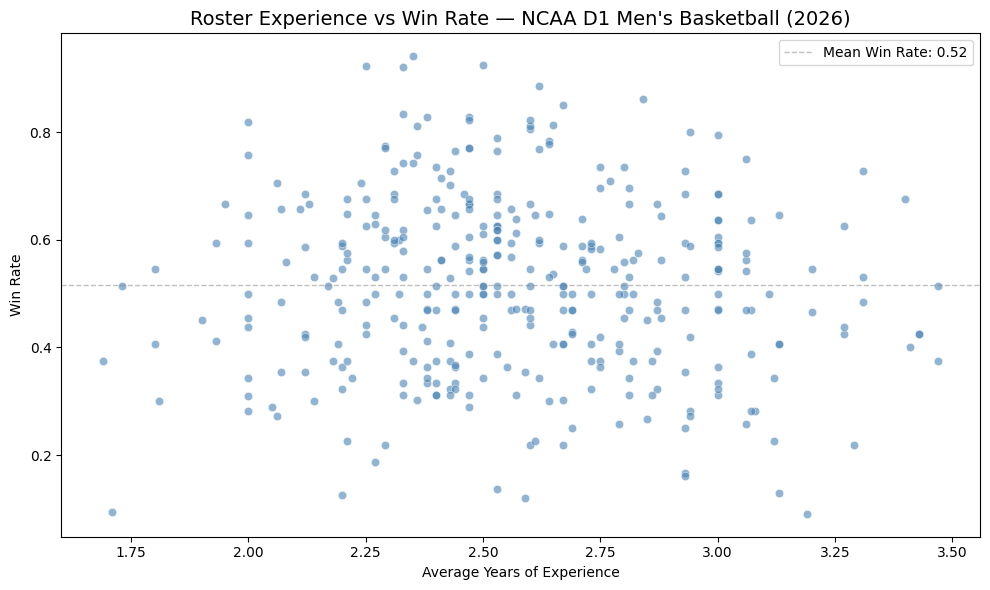

In [72]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df_teams_exp, x="avg_experience", y="WIN_PCT",
                alpha=0.6, color="steelblue", ax=ax)

ax.axhline(df_teams_exp["WIN_PCT"].mean(), color="gray", linestyle="--", linewidth=1, alpha=0.5, label=f"Mean Win Rate: {df_teams_exp['WIN_PCT'].mean():.2f}")
ax.set_title("Roster Experience vs Win Rate — NCAA D1 Men's Basketball (2026)", fontsize=14)
ax.set_xlabel("Average Years of Experience")
ax.set_ylabel("Win Rate")
ax.legend()
plt.tight_layout()
plt.show()

In [73]:
corr = df_teams_exp[["WIN_PCT", "avg_experience"]].corr().round(3)
corr

,WIN_PCT,avg_experience
WIN_PCT,1.000,-0.071
avg_experience,-0.071,1.000


The correlation between roster experience and win rate is -0.071 — effectively zero. 
The scatter confirms this visually: elite programs appear across the full range of 
experience levels. This is a counterintuitive but important finding — in D1 basketball, 
recruiting talent matters more than returning veterans. The best programs reload rather 
than rebuild.

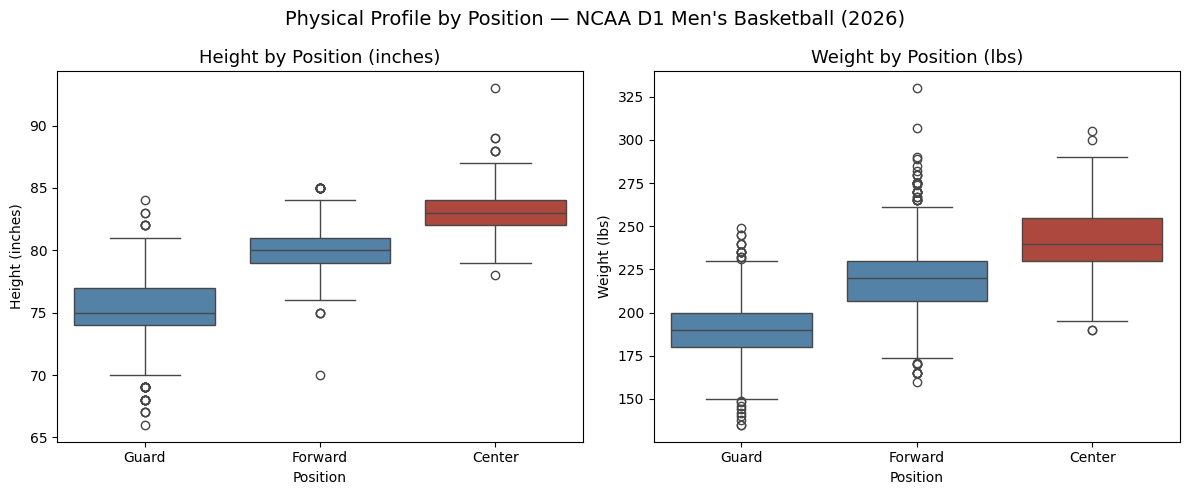

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df_d1_players_clean, x="POSITION_FULL", y="HEIGHT",
            order=["Guard", "Forward", "Center"],
            hue="POSITION_FULL", palette=["steelblue", "steelblue", "#c0392b"],
            legend=False, ax=axes[0])
axes[0].set_title("Height by Position (inches)", fontsize=13)
axes[0].set_xlabel("Position")
axes[0].set_ylabel("Height (inches)")

sns.boxplot(data=df_d1_players_clean, x="POSITION_FULL", y="WEIGHT",
            order=["Guard", "Forward", "Center"],
            hue="POSITION_FULL", palette=["steelblue", "steelblue", "#c0392b"],
            legend=False, ax=axes[1])
axes[1].set_title("Weight by Position (lbs)", fontsize=13)
axes[1].set_xlabel("Position")
axes[1].set_ylabel("Weight (lbs)")

plt.suptitle("Physical Profile by Position — NCAA D1 Men's Basketball (2026)", fontsize=14)
plt.tight_layout()
plt.show()

The physical separation between positions is clear and consistent. Centers are 
significantly taller and heavier than guards with very little overlap in the middle 
of each distribution. Forwards sit between the two extremes. The outliers visible in 
each chart reflect the natural variation in D1 rosters — unusually tall guards and 
lighter-than-average centers exist but are rare. These physical profiles are intuitive 
and serve as a baseline for the feature engineering in the next section.

## Section 7: Feature Engineering

Raw statistics tell part of the story, but derived features often capture more nuanced 
signals. This section engineers new variables from the existing data that better represent 
team quality, roster construction, and performance context. These engineered features will 
serve as inputs to the predictive models in Section 8.

In [75]:
# home, away, and conference win rates
df_teams_exp["HOME_WIN_PCT"] = (df_teams_exp["HOME_WINS"] / 
    (df_teams_exp["HOME_WINS"] + df_teams_exp["HOME_LOSSES"])).round(3)

df_teams_exp["AWAY_WIN_PCT"] = (df_teams_exp["AWAY_WINS"] / 
    (df_teams_exp["AWAY_WINS"] + df_teams_exp["AWAY_LOSSES"])).round(3)

df_teams_exp["CONF_WIN_PCT"] = (df_teams_exp["CONF_WINS"] / 
    (df_teams_exp["CONF_WINS"] + df_teams_exp["CONF_LOSSES"])).round(3)

# scoring efficiency ratio
df_teams_exp["SCORING_EFFICIENCY"] = (df_teams_exp["PPG"] / 
    df_teams_exp["OPP_PPG"]).round(3)

# power conference flag
power_conferences = [
    "Atlantic Coast Conference", "Big Ten Conference", 
    "Big 12 Conference", "Southeastern Conference"
]
df_teams_exp["IS_POWER_CONF"] = df_teams_exp["CONFERENCE"].isin(power_conferences).astype(int)

df_teams_exp[["TEAM_NAME", "HOME_WIN_PCT", "AWAY_WIN_PCT", 
              "CONF_WIN_PCT", "SCORING_EFFICIENCY", "IS_POWER_CONF"]].head(10)

,TEAM_NAME,HOME_WIN_PCT,AWAY_WIN_PCT,CONF_WIN_PCT,SCORING_EFFICIENCY,IS_POWER_CONF
0,Auburn Tigers,0.778,0.200,0.389,1.054,1
1,UAB Blazers,0.471,0.833,0.611,1.074,0
2,South Alabama Jaguars,0.714,0.533,0.611,1.061,0
3,Arkansas Razorbacks,0.944,0.500,0.722,1.113,1
4,Arizona State Sun Devils,0.667,0.182,0.389,0.974,1
5,Arizona Wildcats,0.941,0.900,0.889,1.242,1
6,Cal Poly Mustangs,0.571,0.353,0.500,0.966,0
7,Sacramento State Hornets,0.714,0.000,0.333,0.947,0
8,San Diego State Aztecs,0.875,0.500,0.700,1.102,0
9,San José State Spartans,0.375,0.077,0.150,0.917,0


Five new features are engineered from the existing data. Home, away, and conference win 
rates decompose overall winning percentage into context-specific performance. Scoring 
efficiency — the ratio of points scored to points allowed — captures both offensive and 
defensive quality in a single number above 1.0 means a team scores more than it allows. 
The power conference flag identifies the four conferences with structural recruiting and 
resource advantages identified earlier in the analysis.

In [76]:
outlier_cols = ["WIN_PCT", "PPG", "OPP_PPG", "POINT_DIFF", "SCORING_EFFICIENCY"]

for col in outlier_cols:
    Q1 = df_teams_exp[col].quantile(0.25)
    Q3 = df_teams_exp[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df_teams_exp[(df_teams_exp[col] < lower) | (df_teams_exp[col] > upper)]
    print(f"{col}: {len(outliers)} outliers (lower bound: {lower:.2f}, upper bound: {upper:.2f})")
    if len(outliers) > 0:
        print(outliers[["TEAM_NAME", col]].to_string())
    print()

WIN_PCT: 0 outliers (lower bound: 0.07, upper bound: 0.96)

PPG: 1 outliers (lower bound: 61.05, upper bound: 90.35)
                TEAM_NAME   PPG
158  Alabama Crimson Tide  91.2

OPP_PPG: 2 outliers (lower bound: 60.87, upper bound: 87.22)
                   TEAM_NAME   OPP_PPG
42   IU Indianapolis Jaguars  88.28125
270    North Florida Ospreys  88.15625

POINT_DIFF: 9 outliers (lower bound: -13.75, upper bound: 17.05)
                                 TEAM_NAME  POINT_DIFF
61                     Michigan Wolverines        17.8
64                        Kansas City Roos       -14.6
69                        Duke Blue Devils        18.0
169                      Air Force Falcons       -18.4
196                    Coppin State Eagles       -14.9
215          Gardner-Webb Runnin' Bulldogs       -17.4
218                       Gonzaga Bulldogs        18.1
221                    High Point Panthers        18.4
250  Mississippi Valley State Delta Devils       -18.8

SCORING_EFFICIENCY: 10 

### Outlier Review

IQR-based outlier detection identifies a small number of teams at the extremes of the 
performance distribution. Key observations:

- **PPG**: Alabama (91.2) is the only scoring outlier — consistent with the SEC's 
  high-tempo identity identified in Section 3
- **OPP_PPG**: IU Indianapolis and North Florida allow unusually high points per game, 
  reflecting weaker defensive programs at the bottom of D1
- **POINT_DIFF**: The 9 outliers are the division's best and worst programs — Michigan, 
  Duke, Gonzaga, and High Point at the top; Mississippi Valley State, Air Force, and 
  Gardner-Webb at the bottom. These are genuine performance extremes, not data errors.
- **SCORING_EFFICIENCY**: The same elite programs (Michigan, Duke, Gonzaga, Iowa State, 
  Arizona) appear as high outliers while the weakest programs cluster at the low end

None of these outliers are removed — they represent real programs at the edges of the 
D1 talent spectrum and removing them would distort the analysis. Their presence is 
noted and they will be visible in the model diagnostics in Section 8.

In [77]:
scale_cols = ["WIN_PCT", "PPG", "OPP_PPG", "POINT_DIFF", 
              "HOME_WIN_PCT", "AWAY_WIN_PCT", "CONF_WIN_PCT",
              "SCORING_EFFICIENCY", "avg_experience"]

scaler = StandardScaler()
scaled_values = scaler.fit_transform(df_teams_exp[scale_cols].dropna())
df_scaled = pd.DataFrame(scaled_values, columns=[f"{c}_Z" for c in scale_cols])

df_scaled.describe().round(2)

,WIN_PCT_Z,PPG_Z,OPP_PPG_Z,POINT_DIFF_Z,HOME_WIN_PCT_Z,AWAY_WIN_PCT_Z,CONF_WIN_PCT_Z,SCORING_EFFICIENCY_Z,avg_experience_Z
count,362.00,362.00,362.00,362.00,362.00,362.00,362.00,362.00,362.00
mean,0.00,0.00,0.00,0.00,0.00,-0.00,-0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.59,-2.63,-2.61,-3.24,-3.07,-1.85,-2.50,-2.96,-2.58
25%,-0.70,-0.66,-0.69,-0.61,-0.59,-0.79,-0.72,-0.63,-0.70
50%,-0.01,-0.04,-0.01,0.02,-0.03,-0.18,-0.00,-0.02,-0.12
75%,0.66,0.67,0.71,0.61,0.67,0.67,0.56,0.60,0.67
max,2.58,2.82,3.03,2.65,1.90,3.18,2.50,2.99,2.64


Standard scaling places all features on a common scale with mean 0 and standard deviation 
1. This is required for the logistic regression model in Section 8, where features measured 
in different units (points, ratios, win rates) would otherwise have unequal influence on 
the model coefficients. The min/max z-scores confirm the outlier programs identified above 
— Mississippi Valley State sits 3.24 standard deviations below the mean in point 
differential, while the elite programs cluster at the upper end.

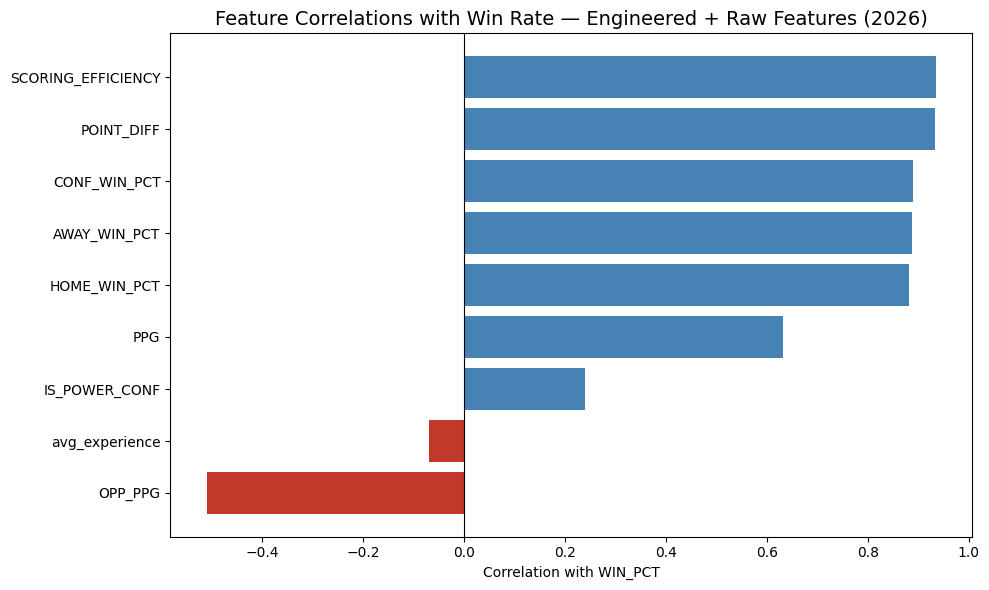

In [78]:
corr_cols_eng = ["WIN_PCT", "POINT_DIFF", "PPG", "OPP_PPG", 
                 "HOME_WIN_PCT", "AWAY_WIN_PCT", "CONF_WIN_PCT",
                 "SCORING_EFFICIENCY", "avg_experience", "IS_POWER_CONF"]

corr_eng = df_teams_exp[corr_cols_eng].corr()["WIN_PCT"].drop("WIN_PCT").sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#c0392b" if x < 0 else "steelblue" for x in corr_eng]
ax.barh(corr_eng.index, corr_eng.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Feature Correlations with Win Rate — Engineered + Raw Features (2026)", fontsize=14)
ax.set_xlabel("Correlation with WIN_PCT")
plt.tight_layout()
plt.show()

The feature correlation chart brings together all engineered and raw features in a single 
view. Key takeaways:

- **Scoring efficiency (0.94) and point differential (0.93)** are the strongest predictors 
  of win rate — both capture the relationship between offense and defense simultaneously
- **Conference, away, and home win rates (0.89-0.90)** are nearly equally predictive, 
  reflecting that teams that win consistently across all contexts are the best teams
- **PPG (0.63)** confirms offense matters but is a weaker signal than net margin
- **IS_POWER_CONF (0.24)** has a modest positive correlation — being in a power conference 
  helps but does not guarantee success
- **avg_experience (-0.07)** is essentially flat — confirming the earlier finding that 
  roster experience does not drive winning
- **OPP_PPG (-0.51)** is the only strongly negative feature — allowing more points 
  is associated with losing, as expected

These correlations directly inform which features enter the predictive models in Section 8.

## Section 8: Predictive Modeling

With a clean dataset and a set of engineered features, we now build two predictive models. 
The first is a linear regression predicting season win rate from team-level features. 
The second is a logistic regression predicting individual game outcomes. Together these 
models quantify how well the factors identified in the EDA can predict performance — 
both at the season level and the individual game level.

### Model 1: Linear Regression — Predicting Season Win Rate

Target variable: `WIN_PCT`  
Features: scoring margin, home/away/conference win rates, scoring efficiency, 
PPG, opponent PPG, experience, and power conference flag — including both raw 
and engineered features.

In [79]:
features_lr = [
    "POINT_DIFF", "PPG", "OPP_PPG",
    "HOME_WIN_PCT", "AWAY_WIN_PCT", "CONF_WIN_PCT",
    "SCORING_EFFICIENCY", "avg_experience", "IS_POWER_CONF"
]
target_lr = "WIN_PCT"

df_model_lr = df_teams_exp[features_lr + [target_lr]].dropna()

X = df_model_lr[features_lr]
y = df_model_lr[target_lr]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print(f"R²:   {r2_score(y_test, y_pred):.3f}")
print(f"MAE:  {mean_absolute_error(y_test, y_pred):.3f}")
print(f"MSE:  {mean_squared_error(y_test, y_pred):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.3f}")

R²:   0.978
MAE:  0.022
MSE:  0.001
RMSE: 0.027


In [80]:
coef_df = pd.DataFrame({
    "Feature": features_lr,
    "Coefficient": lr.coef_
}).sort_values("Coefficient", ascending=False).reset_index(drop=True)
coef_df

,Feature,Coefficient
0,HOME_WIN_PCT,0.397973
1,AWAY_WIN_PCT,0.367769
2,SCORING_EFFICIENCY,0.111807
3,IS_POWER_CONF,0.016337
4,PPG,0.002226
5,POINT_DIFF,0.001927
6,CONF_WIN_PCT,-0.000117
7,OPP_PPG,-0.002515
8,avg_experience,-0.006728


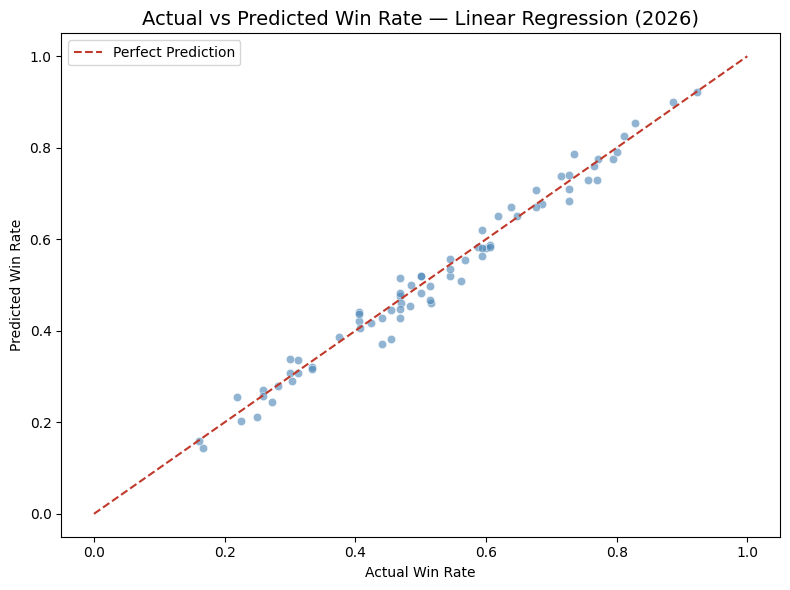

In [81]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, y_pred, alpha=0.6, color="steelblue", edgecolors="white", linewidth=0.5)
ax.plot([0, 1], [0, 1], color="#c0392b", linestyle="--", linewidth=1.5, label="Perfect Prediction")
ax.set_title("Actual vs Predicted Win Rate — Linear Regression (2026)", fontsize=14)
ax.set_xlabel("Actual Win Rate")
ax.set_ylabel("Predicted Win Rate")
ax.legend()
plt.tight_layout()
plt.show()

The linear regression model explains 97.8% of the variance in season win rate (R² = 0.978) 
with a mean absolute error of just 2.2 percentage points. On average the model predicts 
a team's win rate to within about one win over a 33-game season.

The coefficient table reinforces the EDA findings with one important nuance:

- **Home win rate (0.398) and away win rate (0.368)** are the dominant coefficients — 
  teams that win at home and on the road win overall, with away performance slightly 
  more predictive once other factors are controlled for
- **Scoring efficiency (0.112)** is the strongest single performance metric coefficient, 
  confirming that the ratio of points scored to points allowed captures team quality 
  better than raw scoring
- **IS_POWER_CONF (0.016)** adds a small positive boost — power conference membership 
  contributes to win rate beyond what the performance metrics alone explain
- **avg_experience (-0.007)** is negative and near zero — consistent with every prior 
  finding that experience does not drive winning

The actual vs predicted chart confirms the model performs consistently across the full 
range of win rates with no systematic bias toward over or underprediction.

### Model 2: Logistic Regression — Predicting Individual Game Outcomes

Target variable: `WON` (1 = win, 0 = loss)  
We build two versions of this model. Model 1 uses only game location as a feature — 
establishing a baseline that quantifies home court advantage alone. Model 2 adds 
team quality features to measure how much additional predictive power comes from 
knowing who is playing.

In [82]:
# encode location features
df_d1_games["HOME_AWAY_ENC"] = df_d1_games["HOME_AWAY"].map({"home": 1, "away": 0})
df_d1_games["NEUTRAL_SITE_ENC"] = df_d1_games["NEUTRAL_SITE"].astype(int)

# --- Model 1: location only ---
features_log1 = ["HOME_AWAY_ENC", "NEUTRAL_SITE_ENC"]
df_log1 = df_d1_games[features_log1 + ["WON"]].dropna()

X1 = df_log1[features_log1]
y1 = df_log1["WON"]

X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y1, test_size=0.2, random_state=42)

log1 = LogisticRegression(max_iter=1000)
log1.fit(X_train1, y_train1)
y_pred1 = log1.predict(X_test1)

print("--- Model 1: Location Only ---")
print(classification_report(y_test1, y_pred1))
print(f"Accuracy: {accuracy_score(y_test1, y_pred1):.3f}\n")

# --- Model 2: location + team quality ---
team_features = df_teams_exp[["TEAM_NAME", "WIN_PCT", "PPG", "OPP_PPG", 
                               "SCORING_EFFICIENCY", "IS_POWER_CONF", "avg_experience"]]
df_log2 = df_d1_games.merge(team_features, left_on="TEAM", right_on="TEAM_NAME", how="left")

features_log2 = ["HOME_AWAY_ENC", "NEUTRAL_SITE_ENC", "WIN_PCT", "PPG", 
                 "OPP_PPG", "SCORING_EFFICIENCY", "IS_POWER_CONF", "avg_experience"]
df_log2 = df_log2[features_log2 + ["WON"]].dropna()

X2 = df_log2[features_log2]
y2 = df_log2["WON"]

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train2_scaled = scaler.fit_transform(X_train2)
X_test2_scaled = scaler.transform(X_test2)

log2 = LogisticRegression(max_iter=1000)
log2.fit(X_train2_scaled, y_train2)
y_pred2 = log2.predict(X_test2_scaled)

print("--- Model 2: Location + Team Quality ---")
print(classification_report(y_test2, y_pred2))
print(f"Accuracy: {accuracy_score(y_test2, y_pred2):.3f}")

--- Model 1: Location Only ---
              precision    recall  f1-score   support

           0       0.63      0.62      0.63      1128
           1       0.67      0.67      0.67      1263

    accuracy                           0.65      2391
   macro avg       0.65      0.65      0.65      2391
weighted avg       0.65      0.65      0.65      2391

Accuracy: 0.648

--- Model 2: Location + Team Quality ---
              precision    recall  f1-score   support

           0       0.65      0.64      0.65      1128
           1       0.69      0.70      0.69      1263

    accuracy                           0.67      2391
   macro avg       0.67      0.67      0.67      2391
weighted avg       0.67      0.67      0.67      2391

Accuracy: 0.670


In [83]:
y_prob1 = log1.predict_proba(X_test1)[:, 1]
print(f"Model 1 ROC AUC: {roc_auc_score(y_test1, y_prob1):.3f}")

y_prob2 = log2.predict_proba(X_test2_scaled)[:, 1]
print(f"Model 2 ROC AUC: {roc_auc_score(y_test2, y_prob2):.3f}")

Model 1 ROC AUC: 0.647
Model 2 ROC AUC: 0.740


The ROC AUC scores reveal an important distinction between the two models. Model 1, 
using only game location, achieves a ROC AUC of 0.647 — meaningfully better than 
random (0.50) but limited by the single signal of home court advantage. Model 2, 
adding team quality features, jumps to 0.740, a significant improvement that confirms 
team strength adds real predictive power beyond location alone. The gap between the 
two AUC scores (0.093) is larger than the accuracy gap (0.022), suggesting that team 
quality features improve the model's ability to rank predictions by confidence, not 
just flip binary outcomes.

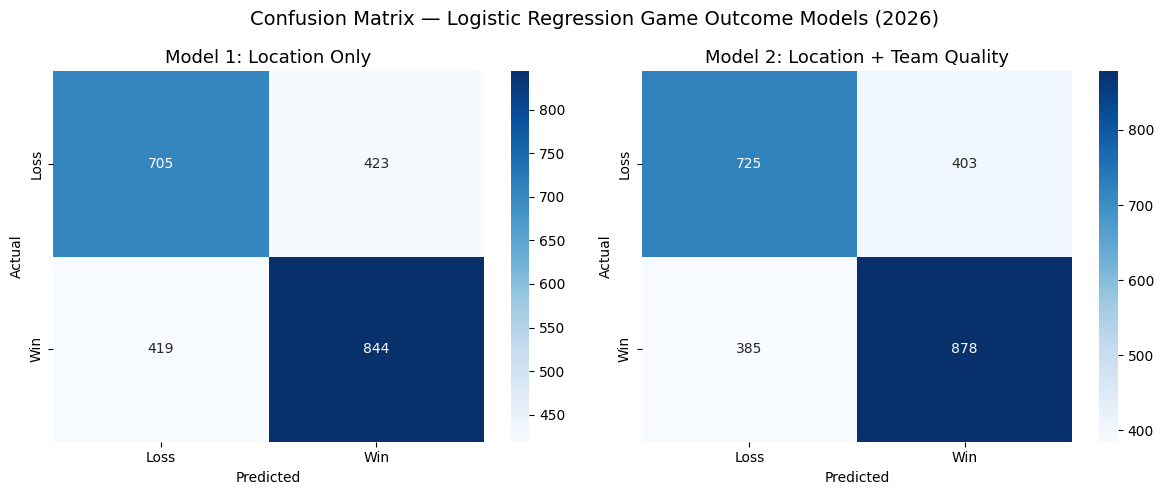

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, title in zip(axes, [y_pred1, y_pred2], 
                              ["Model 1: Location Only", "Model 2: Location + Team Quality"]):
    cm = confusion_matrix(y_test1 if title == "Model 1: Location Only" else y_test2, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Loss", "Win"], yticklabels=["Loss", "Win"])
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrix — Logistic Regression Game Outcome Models (2026)", fontsize=14)
plt.tight_layout()
plt.show()

In [85]:
model_summary = pd.DataFrame({
    "Model": ["Location Only", "Location + Team Quality"],
    "Features": ["Home/Away, Neutral Site", 
                 "Home/Away, Neutral Site, Win Rate, PPG, Opp PPG, Scoring Efficiency, Power Conf, Experience"],
    "Accuracy": [0.648, 0.670],
    "F1 (Win)": [0.67, 0.69],
    "F1 (Loss)": [0.63, 0.65]
})
model_summary

,Model,Features,Accuracy,F1 (Win),F1 (Loss)
0,Location Only,"Home/Away, Neutral Site",0.648,0.67,0.63
1,Location + Team Quality,"Home/Away, Neutral Site, Win Rate, PPG, Opp PP...",0.670,0.69,0.65


The confusion matrices show how each model distributes its correct and incorrect predictions 
across wins and losses.

**Model 1 (Location Only — 64.8% accuracy):**
- Correctly predicts 844 wins and 705 losses out of 2,391 test games
- Misclassifies 423 losses as wins and 419 wins as losses
- Both error types are roughly symmetric — the model has no strong bias toward 
  predicting one outcome over the other

**Model 2 (Location + Team Quality — 67.0% accuracy):**
- Correctly predicts 878 wins and 725 losses — an improvement of 34 wins and 20 
  losses correctly classified compared to Model 1
- Reduces false positives (predicted win, actual loss) from 423 to 403
- The improvement is modest but consistent across both win and loss prediction

The 2.2 percentage point accuracy gain from adding six team quality features confirms 
that game location is the dominant predictable signal in individual game outcomes. 
Knowing where a game is played gets you most of the way there — knowing who is playing 
adds only marginal improvement. This reflects the inherent unpredictability of individual 
college basketball games, where upsets are a structural feature of the sport rather than 
noise in the data.

## Section 9: Conclusion

This analysis examined the 2025–26 NCAA Division I men's basketball season across 362 
programs, 11,954 completed games, and 5,648 rostered players. The central question was 
simple: what separates winning programs in D1 basketball? The answer, it turns out, is 
measurable, consistent, and tells a coherent story across every level of analysis.

### Key Findings

**1. Scoring margin is the dominant signal.**
Point differential correlates at 0.93 with win rate — stronger than any individual 
component. Teams that consistently outscore opponents by large margins win more games, 
full stop. The linear relationship is nearly perfect across all 362 programs.

**2. Power conferences win more, but mid-majors can compete.**
The Big 12, SEC, ACC, and Big Ten all sit above the D1 mean win rate of 0.52, confirming 
that structural advantages in recruiting and resources translate to results. However, 
conferences like the Big East and Atlantic 10 demonstrate that mid-major programs can 
compete at a high level with the right investment.

**3. Home court advantage is real and quantifiable.**
Home teams win 67.9% of games versus 35.6% for away teams — a 32 percentage point gap. 
Neutral site games land at exactly 50.2%, confirming the effect is structural rather than 
coincidental. Location alone predicts game outcomes at 64.8% accuracy.

**4. The AP poll validates our metrics.**
Ranked teams average a 0.769 win rate and +11.72 point differential compared to 0.498 
and +0.91 for unranked programs. The external benchmark and our internal metrics tell 
the same story.

**5. Roster experience does not predict winning.**
The correlation between average roster experience and win rate is -0.071 — effectively 
zero. Elite programs appear across the full range of experience levels. In D1 basketball, 
recruiting talent matters more than returning veterans.

**6. Predictive models confirm the EDA.**
The linear regression model predicts season win rate with R² = 0.978 and MAE of 2.2 
percentage points using engineered features. The logistic regression predicts individual 
game outcomes at 67.0% accuracy — meaningfully better than a coin flip using only 
pre-game information.

### Limitations

- **Single season**: This analysis covers only the 2025–26 season. Multi-year data would 
  allow trend analysis and more robust modeling.
- **No strength of schedule adjustment**: Win rates are not adjusted for opponent quality, 
  meaning a 20-win team in a weak conference is treated the same as a 20-win team in the SEC.
- **Roster data completeness**: Weight (4.9%) and other player attributes are missing for 
  some players, limiting the depth of physical profile analysis.

### Future Work

If more time were available, the next steps would be:
- Incorporate NCAA tournament seeding and outcomes to evaluate which regular season 
  metrics predict March success
- Add KenPom or BartTorvik efficiency ratings as an external benchmark
- Build a strength of schedule adjustment to make cross-conference comparisons more meaningful
- Expand to multiple seasons to identify program trajectory and trend analysis
- Explore clustering models to identify program archetypes across the D1 landscape

## Appendix

In [86]:
df_d1_teams.head()

,TEAM_ID,SEASON,TEAM_NAME,ABBREVIATION,LOCATION,MASCOT,CONFERENCE,DIVISION,WINS,LOSSES,...,POINT_DIFF,HOME_WINS,HOME_LOSSES,AWAY_WINS,AWAY_LOSSES,CONF_WINS,CONF_LOSSES,AP_RANK,AP_POINTS,IS_RANKED
0,2,2026,Auburn Tigers,AUB,Auburn,Tigers,Southeastern Conference,NCAA Division I,22.0,16.0,...,4.2,14.0,4.0,2.0,8.0,7.0,11.0,NaN,NaN,0
1,5,2026,UAB Blazers,UAB,UAB,Blazers,American Conference,NCAA Division I,20.0,12.0,...,5.4,8.0,9.0,10.0,2.0,11.0,7.0,NaN,NaN,0
2,6,2026,South Alabama Jaguars,USA,South Alabama,Jaguars,Sun Belt Conference,NCAA Division I,21.0,12.0,...,4.3,10.0,4.0,8.0,7.0,11.0,7.0,NaN,NaN,0
3,8,2026,Arkansas Razorbacks,ARK,Arkansas,Razorbacks,Southeastern Conference,NCAA Division I,28.0,9.0,...,9.2,17.0,1.0,5.0,5.0,13.0,5.0,13.0,716.0,1
4,9,2026,Arizona State Sun Devils,ASU,Arizona State,Sun Devils,Big 12 Conference,NCAA Division I,17.0,16.0,...,-2.0,10.0,5.0,2.0,9.0,7.0,11.0,NaN,NaN,0


In [87]:
df_d1_players.head()

,ATHLETE_ID,TEAM_ID,SEASON,TEAM_NAME,CONFERENCE,PLAYER_NAME,FIRST_NAME,LAST_NAME,JERSEY,POSITION,POSITION_NAME,HEIGHT,WEIGHT,YEAR,YEARS_EXP,CITY,STATE,COUNTRY,ACTIVE,POSITION_FULL
0,5311501,2,2026,Auburn Tigers,Southeastern Conference,Abdul Bashir,Abdul,Bashir,2,G,Guard,79.0,165.0,Junior,3.0,Omaha,NE,USA,True,Guard
1,5311504,2,2026,Auburn Tigers,Southeastern Conference,Jeremiah Bowman,Jeremiah,Bowman,20,G,Guard,79.0,205.0,Freshman,1.0,Glassboro,NJ,USA,True,Guard
2,5238198,2,2026,Auburn Tigers,Southeastern Conference,Drake Cardwell,Drake,Cardwell,17,G,Guard,77.0,195.0,Sophomore,2.0,Augusta,GA,USA,True,Guard
3,5311502,2,2026,Auburn Tigers,Southeastern Conference,Elyjah Freeman,Elyjah,Freeman,6,G,Guard,80.0,185.0,Sophomore,2.0,Palm Beach,FL,USA,True,Guard
4,5075625,2,2026,Auburn Tigers,Southeastern Conference,Keyshawn Hall,Keyshawn,Hall,7,F,Forward,79.0,225.0,Senior,4.0,Cleveland,OH,USA,True,Forward


In [88]:
df_d1_games.head()

,TEAM_ID,SEASON,SEASON_TYPE,TEAM,CONFERENCE,GAME_ID,GAME_DATE,OPPONENT_ID,OPPONENT,HOME_AWAY,NEUTRAL_SITE,ATTENDANCE,WON,TEAM_SCORE,OPP_SCORE,SCORE_MARGIN,LOCATION,HOME_AWAY_ENC,NEUTRAL_SITE_ENC
0,311,2026,2,Maine Black Bears,America East Conference,401817141,2025-11-04 01:00:00,45,George Washington Revolutionaries,away,False,2043,0,47,67,-20,Away,0,0
1,339,2026,2,Evansville Purple Aces,Missouri Valley Conference,401828911,2025-11-07 17:00:00,502,Calumet St. Joseph Crimson Wave,home,False,5561,1,92,50,42,Home,1,0
2,339,2026,2,Evansville Purple Aces,Missouri Valley Conference,401830249,2025-12-21 21:00:00,2181,Drake Bulldogs,home,False,4207,0,65,66,-1,Home,1,0
3,2199,2026,2,Eastern Michigan Eagles,Mid-American Conference,401814567,2026-02-14 19:00:00,2711,Western Michigan Broncos,home,False,1804,0,62,76,-14,Home,1,0
4,2132,2026,2,Cincinnati Bearcats,Big 12 Conference,401819850,2025-12-30 00:00:00,288,Lipscomb Bisons,home,False,9793,1,89,62,27,Home,1,0


In [89]:
df_d1_games_unique.head()

,GAME_ID,SEASON,SEASON_TYPE,GAME_DATE,TEAM_1_ID,TEAM_1,TEAM_1_SCORE,TEAM_2_ID,TEAM_2,TEAM_2_SCORE,SCORE_MARGIN
0,401804832,2026,2,2025-12-30 00:00:00,55,Jacksonville State Gamecocks,78,98,Western Kentucky Hilltoppers,67,11
1,401804873,2026,2,2026-01-10 22:00:00,338,Kennesaw State Owls,88,55,Jacksonville State Gamecocks,82,6
2,401804887,2026,2,2026-01-17 19:00:00,2229,Florida International Panthers,63,2534,Sam Houston Bearkats,76,13
3,401804897,2026,2,2026-01-24 00:00:00,2393,Middle Tennessee Blue Raiders,58,55,Jacksonville State Gamecocks,75,17
4,401804942,2026,2,2026-02-21 21:00:00,2335,Liberty Flames,73,98,Western Kentucky Hilltoppers,94,21
